<a href="https://colab.research.google.com/github/biswas-bit/Deep-learning/blob/main/NLP_for__sector_classificationipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets evaluate accelerate torch scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00


In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "google/muril-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6      # Number of sectors
)

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

In [3]:
import pandas as pd

data = {
    "text": [
        # ==========================================
        # LABEL 0: Road (सडक तथा यातायात) - ५० वटा
        # ==========================================
        "हाम्रो वडा नं. ४ को मुख्य सडकमा ठूला-ठूला खाल्डाखुल्डी परेकाले आवतजावतमा निकै कठिनाइ भएको छ।",
        "कृपया पिपलबोट चोकको भित्री सडक पिच गरिदिनुहुन विनम्र अनुरोध गर्दछु।",
        "किन पिच गरेको दुई महिनामै सडक भत्कियो, यसको गुणस्तर कसले हेर्ने?",
        "वडा नं. १५ को बसपार्क नजिकैको सडक भत्केर आज बिहानदेखि दुर्घटनाको जोखिम निकै बढेको छ।",
        "चार दिनदेखि परेको पानीले गर्दा विद्यालय नजिकैको बाटो हिलो भएर बालबालिकाहरू हिँड्नै नसक्ने भएका छन्।",
        "यो मुख्य सडकको खाल्डो नमिलाएका कारण दैनिक जसो मोटरसाइकल दुर्घटना भइरहेका छन्।",
        "बारम्बार अनुरोध गर्दा पनि किन हाम्रो टोलको सडक मर्मतमा ध्यान दिइँदैन?",
        "स्थानीय पुल नजिकैको सडक किनार कटान भएकाले गाडी गुडाउन निकै डरमर्दो स्थिति सिर्जना भएको छ।",
        "आज बिहानदेखि पहिरो झरेर भित्री सडक पूर्ण रूपमा अवरुद्ध भएको छ, तत्काल डोजर पठाइयोस्।",
        "बजार क्षेत्रको व्यस्त सडकमा फुटपाथ मिचेर पसल थाप्दा पैदलयात्रीलाई हिँड्न सामान्य असुविधा भएको छ।",
        "टोलभरिका सडक खनेर खानेपानीको पाइप हालियो तर एक महिना बित्दा पनि पिच गरिएन।",
        "अहिले मुख्य सडकको दायाँबायाँ खाल्डा खनेर अलपत्र छाडिएकाले पैदल हिँड्न पनि सकस छ।",
        "सम्बन्धित निकायले वडा नं. ९ को लिङ्क रोड कहिलेसम्ममा कालोपत्रे गरिसक्ने योजना बनाएको छ?",
        "कहिलेसम्म हामीले यो धुलाम्मे सडकको सास्ती खेप्ने हो, नगरपालिका किन मौन छ?",
        "धेरै पटक लिखित निवेदन दिँदा पनि तीन महिनादेखि मन्दिर नजिकैको भत्केको बाटो बनाइएको छैन।",
        "हाम्रो वडा नं. २ मा तीव्र गतिमा गुड्ने गाडीहरूका कारण सडक पार गर्न निकै डर लाग्ने गरेको छ।",
        "कृपया बसपार्क क्षेत्रको बाटोमा गति रोधक (Speed Breaker) हालिदिनुहुन अनुरोध छ।",
        "किन यहाँको सडक ठेकेदारले काम बीचैमा छोडेर भाग्दा पनि कारबाही हुँदैन?",
        "वडा नं. ७ को खोला किनारको बाटो बाढीले बगाएर आवतजावत ठप्प भएको छ।",
        "दुई दिनदेखि सडकको बीचमै निर्माण सामग्री थुपारेर राखिएकाले बाटो बन्द जस्तै भएको छ।",
        "यो गल्ली यति साँघुरो छ कि एम्बुलेन्स समेत छिर्न सक्ने अवस्था छैन, फराकिलो बनाइयोस्।",
        "बारम्बार दुर्घटना हुने चोकमा ट्राफिक लाइटको व्यवस्था कहिले हुन्छ?",
        "स्थानीय बजार क्षेत्रको सडकमा जथाभाबी गाडी पार्किङ गर्नाले दैनिक जाम हुने गरेको छ।",
        "आज दिउँसो विद्यालय अगाडिको सडकमा एउटा स्कुटर खाल्डोमा परेर दुर्घटना भयो।",
        "बजार जाने मुख्य सडकमा ठूला गाडी गुड्न निषेध गरियोस् किनभने बाटो धेरै कमजोर छ।",
        "टोलभरिका भित्री सडकहरूमा ढुङ्गा छाप्ने काम तत्काल सुरु गर्न सुझाव दिन चाहन्छु।",
        "अहिले पानी पर्ने बित्तिकै सडक जलमग्न भएर पोखरी जस्तै बन्ने गरेको छ।",
        "सम्बन्धित निकायले वडा नं. १८ को पक्की सडक भत्किँदा पनि मर्मतमा चासो देखाएको छैन।",
        "कहिलेसम्म धुलो खाएर बस्ने, सडकमा पानी हाल्ने व्यवस्था तत्काल गरियोस्।",
        "धेरै पटक भनियो तर पुल नजिकैको सडकको मोड निकै साँघुरो भएकाले दुर्घटना बढेको बढ्यै छ।",
        "हाम्रो टोलको बाटो हिउँदमा धुलो र बर्खामा हिलो भएर दैनिक सास्ती भोग्नुपरेको छ।",
        "कृपया हस्पिटल जाने छोटो बाटोको खाल्डोहरू चाँडै पुरिदिनुहोला।",
        "किन सडक खन्ने बेला एउटा कार्यालय र पुर्ने बेला अर्को कार्यालयले समन्वय गर्दैनन्?",
        "वडा नं. ३१ को भित्री बाटोमा ग्राभेल हालेको दुई हप्तामै सबै बगेर गयो।",
        "दुई हप्तादेखि सडक किनारको पर्खाल भत्केर बाटोमै खसेको छ, हटाउने कोही छैन।",
        "यो नयाँ पिच सडक एक महिनामै उप्किएर गिटीहरू जताततै छरिएका छन्।",
        "बारम्बार ताकेता गर्दा पनि वडा कार्यालयले सडक विस्तारको काम अघि बढाएन।",
        "स्थानीय बासिन्दा मिलेर श्रमदान त गर्यौँ तर मुख्य सडक मर्मत गर्न बजेट पुगेन।",
        "आज भित्री गल्लीमा गुड्ने ट्रयाक्टरले बाटो पूरै बिगारेर हिँड्नै नहुने बनाएको छ।",
        "बजारको मुख्य चोकमा आकाशे पुल नहुँदा बुढाबुढी र बालबालिकालाई बाटो काट्न गाह्रो भयो।",
        "टोलभित्र ठूला मालवाहक ट्रकहरू छिर्न नपाउने नियम बनाउनु पर्ने देखिन्छ।",
        "अहिलेको वर्षाले गर्दा नदी किनारको सडक पूरै बगाउने जोखिममा रहेको छ।",
        "सम्बन्धित निकायले वडा नं. ३ को उकालो सडकमा रेलिङ हाल्ने काम किन रोकेको?",
        "कहिलेसम्म यो खाल्डै खाल्डो भएको बाटोमा यात्रा गर्नुपर्ने हो, ज्यानको जोखिम भयो।",
        "धेरै पटक दुर्घटना भइसकेको मन्दिरको मोडमा ऐना (Convex Mirror) राखिदिनुहोला।",
        "हाम्रो गाउँ जोड्ने एकमात्र पुल निर्माण कार्य तीन वर्षदेखि अलपत्र परेको छ।",
        "कृपया वडा नं. ११ को बजार क्षेत्रमा फुटपाथ खाली गराउने अभियान चलाउनुहोस्।",
        "किन सडक विभागले यो व्यस्त सडकको मर्मत रातिको समयमा नगरेर दिउँसो गर्छ?",
        "वडा नं. २५ को बसपार्क जाने बाटो हिलोले गर्दा पैदलयात्रीका लागि विजोग बनेको छ।",
        "एक हप्तादेखि सडकको नाली सफा गर्दा निकालिएको माटो बाटोमै छाडिँदा दुर्घटना बढेको छ।",

        # ==========================================
        # LABEL 1: Water (खानेपानी) - ५० वटा
        # ==========================================
        "हाम्रो वडा नं. ३ को धारामा एक हप्तादेखि एक थोपा पनि पानी आएको छैन, हाहाकार मच्चिएको छ।",
        "कृपया बजार क्षेत्रमा वितरण भइरहेको धमिलो पानी तत्काल फिल्टर गरेर मात्र पठाउनुहोला।",
        "किन हामीले महसुल बुझाउँदा पनि खानेपानीको ट्याङ्कर किन्नुपर्ने अवस्था आएको हो?",
        "वडा नं. ९ को मुख्य पाइपलाइन आज बिहानदेखि फुटेर हजारौँ लिटर पानी सडकमा खेर गइरहेको छ।",
        "चार दिनदेखि टोलभरि पानी नआउँदा दैनिक शौच गर्न र खाना पकाउन समेत गाह्रो भएको छ।",
        "यो गर्मी महिनामा पानीको आपूर्ति बढाउनुको साटो उल्टै कटौती गरिएकोमा आपत्ति छ।",
        "बारम्बार गुनासो गर्दा पनि खानेपानी संस्थानले वितरण प्रणालीमा सुधार गरेन।",
        "स्थानीय इनारको पानी सुकेकाले अब हामी पूर्ण रूपमा सरकारी धाराकै भर पर्नुपरेको छ।",
        "आज वितरण गरिएको पानीमा कडा गन्ध र किराहरू भेटिएकाले स्वास्थ्यमा गम्भीर असर पर्ने डर छ।",
        "बजार क्षेत्रका सार्वजनिक धाराहरू मर्मत सम्भार गरे गरिब नागरिकलाई सजिलो हुने थियो।",
        "टोलभरि हप्तामा एक दिन मात्र पानी आउँछ, त्यो पनि जम्मा आधा घण्टा, कसरी पुर्याउनु?",
        "अहिले मुख्य ट्याङ्की सफा नगरेका कारण धारा खोल्दा धमिलो र लेदो पानी आउँछ।",
        "सम्बन्धित निकायले वडा नं. १४ मा नयाँ खानेपानी आयोजना कहिले सुरु गर्छ?",
        "कहिलेसम्म हामीले पानीकै लागि राति २ बजे उठेर लाइन बस्नुपर्ने हो?",
        "धेरै पटक मिटर बिग्रिएको निवेदन दिँदा पनि तीन महिनादेखि फेर्न कोही आएको छैन।",
        "हाम्रो वडा नं. ७ को तल्लो टोलमा पानी आउने तर माथिल्लो टोलमा कहिल्यै नचढ्ने समस्या छ।",
        "कृपया पिउने पानीको पाइप र ढलको पाइप सँगै नबिछ्याउनु होला, पानी मिसिने जोखिम छ।",
        "किन खानेपानी कार्यालयले बिना सूचना हप्तौँसम्म पानी बन्द गरिदिन्छ?",
        "वडा नं. २ को विद्यालय नजिकैको सार्वजनिक धारा दुई हप्तादेखि टुटुल फुटेर पानी बगिरहेको छ।",
        "दुई दिनदेखि पानी नआएका कारण कपडा धुन र सरसफाइ गर्न निकै सास्ती भएको छ।",
        "यो धाराको पानी खाँदा धेरै जना बिरामी परे, पानीको ल्याब टेस्ट गरियोस्।",
        "बारम्बार माग गर्दा पनि हाम्रो सुकुम्वासी बस्तीमा खानेपानीको लाइन जोडिएन।",
        "स्थानीय खोलाको पानी प्रदूषित भएकाले शुद्धीकरण प्लान्ट स्थापना गर्न जरुरी छ।",
        "आज बेलुका आउनुपर्ने पानीको पालोमा किन पानी नआएको, कतै पाइप त ब्लक भएन?",
        "बजार क्षेत्रमा जथाभाबी बोरिङ खन्दा जमिनमुनिको पानीको स्रोत सुक्दै गएको छ।",
        "टोलभरिका पुराना र खिया लागेका फलामका पाइपहरू प्लास्टिकको पाइपले फेर्न सुझाव दिन्छु।",
        "अहिले पानीको महसुल अनलाइनबाट तिर्ने व्यवस्था नहुँदा लाइन बस्न निकै झन्झट छ।",
        "सम्बन्धित निकायले पानीको वैकल्पिक स्रोत पहिचान गरी आपूर्ति सहज बनाउनुपर्छ।",
        "कहिलेसम्म पानीको जार किनेर साध्य चल्छ, गरिबको घरमा धारा कहिले जोडिन्छ?",
        "धेरै पटक भन्दा पनि मिटर रिडरले प्रत्येक महिना घरमा आएर रिडिङ गर्दैनन्।",
        "हाम्रो वडा नं. २१ मा पानीको प्रेसर निकै कम भएकाले भुइँतलामा पनि पानी झर्दैन।",
        "कृपया अस्पताल क्षेत्रमा २४ सै घण्टा खानेपानी उपलब्ध गराउने व्यवस्था मिलाइयोस्।",
        "किन वितरणमा विभेद गरिन्छ, भीआईपी टोलमा सधैँ पानी आउने हाम्रोमा नआउने?",
        "वडा नं. ३५ को दुर्गम बस्तीमा आजसम्म खानेपानीको एउटा पनि सरकारी पाइप पुगेको छैन।",
        "दुई महिनादेखि खानेपानीको ट्याङ्कीमा ब्लीचिङ पाउडर नहालेको कुरा बुझिन आएको छ।",
        "यो पानीको पाइपलाइन सडक खन्दा भत्किएपछि कसैले बनाउने जिम्मेवारी लिएन।",
        "बारम्बार ताकेता गर्दा पनि पानी वितरण गर्ने कर्मचारीले समय तालिका पालना गर्दैनन्।",
        "स्थानीय मुहानमा पहिरो जाँदा सहरभरि पानीको हाहाकार मच्चिएको छ।",
        "आज बिहान धारा खोल्दा पानीसँगै लेदो माटो आएर बाल्टिन पूरै फोहोर भयो।",
        "बजारको चोक चोकमा सित्तैमा पिउने पानी पाइने वाटर एटिएम (Water ATM) राख्न पाए हुन्थ्यो।",
        "टोलभित्र पानीको नयाँ पाइप बिछ्याउन उपभोक्ता समितिले धेरै रकम माग गर्यो।",
        "अहिलेको खडेरीले गर्दा इनार र कुवाहरू सबै सुकेर गाउँ नै काकाकुल भएको छ।",
        "सम्बन्धित निकायले वडा नं. ८ मा डिप बोरिङ गर्ने बजेट कहाँ फ्रिज गर्यो?",
        "कहिलेसम्म दलालहरूसँग महँगोमा ट्याङ्करको पानी किनेर गुजारा चलाउने हामीले?",
        "धेरै पटक गुनासो गरेपछि मात्र आज खानेपानीको प्राविधिक टोली गाउँमा आएको छ।",
        "हाम्रो वडामा पानीको मुख्य साँचो (Valve) चलाउने मान्छेले पैसा खाएर बढी पानी दिन्छ।",
        "कृपया पानीको पाइपलाइन विस्तार गर्दा खेतीयोग्य जमिन नष्ट नहुने गरी गर्नुहोस्।",
        "किन पानीको महसुल बढाउने तर सेवा भने झन् झन् खत्तम बनाउँदै लैजाने?",
        "वडा नं. १६ को स्वास्थ्य चौकीमा पानी नभएर बिरामीहरू बाहिरै शौचालय जान बाध्य छन्।",
        "एक हप्तादेखि धारामा हावा मात्र आउँछ तर मिटर भने फनफनी घुमेर पैसा उठ्छ।",

        # ==========================================
        # LABEL 2: Electricity (विद्युत तथा बत्ती) - ५० वटा
        # ==========================================
        "हाम्रो वडा नं. ६ को मुख्य सडकमा रहेका सडकबत्तीहरू एक महिनादेखि निभेका छन्, जसले गर्दा रातको समयमा हिँड्न निकै डर लाग्छ।",
        "कृपया ट्रान्सफर्मर पड्किएर अन्धकार भएको हाम्रो टोलमा आजै नयाँ ट्रान्सफर्मर जडान गरिदिनुहोला।",
        "किन बिना सूचना दिनमा १० पटक लाइट जान्छ, यसले इलेक्ट्रोनिक्स सामान सबै बिग्रियो?",
        "वडा नं. १० को चोकमा आज बिहानदेखि उच्च भोल्टेजको तार चुँडिएर सडकमा झरेको छ, ठूलो दुर्घटनाको जोखिम छ।",
        "तीन दिनदेखि विद्युत अवरुद्ध हुँदा मोबाइल चार्ज गर्न र अनलाइन काम गर्न समेत पाइएको छैन।",
        "यो भोल्टेजको उतारचढाव (Fluctuation) ले गर्दा घरका फ्रीज र टिभीहरू जलिरहेका छन्।",
        "बारम्बार फोन गर्दा पनि नो-लाइटको नम्बर सधैँ व्यस्त आउँछ वा कसैले उठाउँदैन।",
        "स्थानीय मन्दिर नजिकैको बिजुलीको पोल ढल्न लागेको छ, बेलैमा मर्मत गरियोस्।",
        "आज दिउँसोदेखि जिर्ण विद्युतको पोल सडकको बीचतिर ढल्केकाले आवतजावतमा कठिनाइ भएको छ।",
        "बजार क्षेत्रका बिजुलीका पोलमा जताततै इन्टरनेट र केबलका तारहरू गुजुल्टो पारेर राख्दा आगलागीको खतरा छ।",
        "टोलभरि रातिको समयमा अँध्यारो हुने भएकाले चोरी र डकैतीका घटनाहरू बढ्न थालेका छन्।",
        "अहिलेको हावाहुरीले गर्दा रूखका हाँगाहरू बिजुलीको तारमा अल्झिएर बारम्बार लाइन काटिन्छ।",
        "सम्बन्धित निकायले वडा नं. १३ मा स्मार्ट सडकबत्ती (Smart Street Light) कहिले जडान गर्छ?",
        "कहिलेसम्म हामीले यो लो-भोल्टेजको समस्या भोग्ने, बत्ती बले पनि डिम मात्र हुन्छ?",
        "धेरै पटक भन्दा पनि दुई हप्तादेखि हाम्रो घर अगाडिको सडकबत्ती मर्मत गरिएको छैन।",
        "हाम्रो वडा नं. १ को विद्युत महसुल काउन्टरमा कर्मचारी नहुँदा घण्टौँ लाइन बस्नुपर्छ।",
        "कृपया नाङ्गो तारहरू हटाएर इन्सुलेटेड (Insulated) केबल तारहरू प्रयोग गरिदिनुहोला।",
        "किन विद्युत प्राधिकरणले उद्योगहरूलाई मात्र बत्ती दिने र सर्वसाधारणलाई लोडसेडिङ गर्ने?",
        "वडा नं. २५ को विद्यालय नजिकै झाडीभित्र लुकेको ट्रान्सफर्मरबाट आज बिहान झिल्का निस्किरहेको छ।",
        "दुई दिनदेखि हाम्रो गल्लीमा विद्युतको नयाँ पोल ल्याएर राखे पनि गाडिएको छैन।",
        "यो नयाँ बस्तीमा बिजुलीको लाइन नहुँदा मानिसहरू अझै टुकी बाल्न बाध्य छन्।",
        "बारम्बार बत्ती जाँदा विद्यार्थीहरूको जाँचको तयारीमा निकै ठूलो बाधा पुगेको छ।",
        "स्थानीय खोला किनारमा रहेका विद्युतका पोलहरू बाढीले बगाउने उच्च जोखिममा छन्।",
        "आज राति अचानक भोल्टेज बढेर घरका सबै सिएफएल चिमहरू पड्किए।",
        "बजार क्षेत्रमा भूमिगत (Underground) वायरिङ गर्ने काम कहिलेसम्म सकिन्छ?",
        "टोलभित्रका पुराना काठका पोलहरू विस्थापित गरी फलामका पोल राख्न सुझाव दिन्छु।",
        "अहिले विद्युत प्राधिकरणको एपबाट रिडिङ हाल्न खोज्दा सर्भर चल्दैन।",
        "सम्बन्धित निकायले वडा नं. २८ को मिटर बक्स वितरण कार्य किन ढिलाइ गरेको?",
        "कहिलेसम्म बिना जानकारी बत्ती काट्ने हो, कम्तीमा कार्यतालिका त सार्वजनिक गर।",
        "धेरै पटक लिखित अनुरोध गर्दा पनि कृषि मिटर पाउन सकिएन, सिँचाइ गर्न गाह्रो भयो।",
        "हाम्रो वडा नं. ३० मा सडकबत्ती दिउँसो पनि बलिरहन्छ तर राति भने निभ्छ।",
        "कृपया बसपार्क क्षेत्रमा हाइमास्ट लाइट (High Mast Light) जडान गरेर उज्यालो बनाइदिनुहोला।",
        "किन नयाँ ग्राहकलाई मिटर दिन ६ महिनासम्म कुराउने गरिन्छ, यहाँ पनि घुस चाहिन्छ?",
        "वडा नं. ३ को भित्री सडकमा झाडीले बिजुलीको तार छोपेर हिँड्नै डरमर्दो छ।",
        "दुई हप्तादेखि हाम्रो घरको थ्री-फेज लाइन काटिएको छ, उद्योग ठप्प भयो।",
        "यो विद्युत प्राधिकरणको लापरबाहीले गर्दा पोलमा चढेका प्राविधिकको करेन्ट लागेर मृत्यु भयो।",
        "बारम्बार ताकेता गर्दा पनि प्राधिकरणले सडक विस्तारका क्रममा बीचमा परेका पोल सारेन।",
        "स्थानीय टोल सुधार समितिले उठाएको सडकबत्तीको पैसा वडा अध्यक्षले अन्तै खर्च गरे।",
        "आज चोकमा एउटा मालवाहक ट्रकले बिजुलीको तार चुँडाएर भागेछ, बत्ती निभ्यो।",
        "बजार क्षेत्रमा सोलार बत्तीहरू जडान गरे लोडसेडिङको बेला पनि सजिलो हुने थियो।",
        "टोलभित्र नयाँ ट्रान्सफर्मर राख्न उपयुक्त जग्गा नपाउँदा काम रोकिएको छ।",
        "अहिले डिजिटल मिटर आएदेखि बिजुलीको बिल पहिलेभन्दा दोब्बर आउन थालेको छ।",
        "सम्बन्धित निकायले वडा नं. ११ को बत्तीको समस्या समाधान गर्न चासो दिएन।",
        "कहिलेसम्म प्राधिकरणको लापरबाही सहने, मिटर रिडर महिना मरेपछि मात्र आउँछन्।",
        "धेरै पटक भनियो तर विद्युतको तार भुइँबाट जम्मा ५ फिट माथि झुण्डिएको छ।",
        "हाम्रो घर अगाडिको पोलबाट छिमेकीले जथाभाबी हुकिङ गरेर बत्ती बालेका छन्।",
        "कृपया अनलाइन बिलिङ प्रणालीलाई अझ सरल र भरपर्दो बनाउनुहोला।",
        "किन नो-लाइटका कर्मचारीहरू गुनासो आउँदा रुखो व्यवहार गर्छन्?",
        "वडा नं. २१ को स्वास्थ्य चौकीमा बत्ती नहुँदा प्रसूति सेवामा ठूलो समस्या परेको छ।",
        "एक हप्तादेखि बत्ती आउने-जाने क्रमले गर्दा अनलाइन परीक्षा दिने विद्यार्थी फेल भए।",

        # ==========================================
        # LABEL 3: Drainage (ढल निकास) - ५० वटा
        # ==========================================
        "हाम्रो वडा नं. ८ को मुख्य गल्लीमा चार दिनदेखि ढल फुटेर बाटोभरि फोहोर पानी बगिरहेको छ, जसले गर्दा आवतजावतमा कठिनाइ भएको छ।",
        "कृपया हस्पिटल अगाडिको जाम भएको ढल सफा गरिदिनुहुन विनम्र अनुरोध गर्दछु।",
        "किन हरेक वर्ष बर्खामा ढल भरिएर मानिसहरूको घरभित्र फोहोर पानी पस्छ?",
        "वडा नं. १४ को मन्दिर नजिकै आज बिहानदेखि ढलको ह्युम पाइप फुटेर सडक भासिएको छ।",
        "एक हप्तादेखि विद्यालय जाने बाटोको नाली जाम भएर बजार क्षेत्रभरि दुर्गन्ध फैलिएको छ।",
        "यो ढल निकासको ढक्कन खुल्ला छोडिएकाले रातिको समयमा मान्छे खस्ने दुर्घटनाको जोखिम छ।",
        "बारम्बार वडामा भन्दा पनि ढल सफा गर्ने मेसिन (Jetting Machine) पठाइएन।",
        "स्थानीय खोलामा सिधै ढल मिसाउँदा नदी किनारका बस्तीहरू बस्नै नसक्ने गरी गन्हाउने भएका छन्।",
        "आज बिहानदेखि परेको पानीले गर्दा चोकको नाली ओभरफ्लो भएर सडक पोखरी बनेको छ।",
        "बजार क्षेत्रमा ठूला ह्युम पाइप हालेर ढलको स्थायी समाधान गरे उत्तम हुने थियो।",
        "टोलभरि ढलको पानी उम्लिएर सडकमा आउँदा दैनिक हिँडडुल गर्न सामान्य असुविधा भएको छ।",
        "अहिले ढल खन्ने बहानामा पुरानो नाली पनि भत्काएर अलपत्र छाडिएको छ।",
        "सम्बन्धित निकायले वडा नं. २० को ढल व्यवस्थापन कार्य कहिले सुरु गर्छ?",
        "कहिलेसम्म हामीले यो मानव मलमूत्र मिसिएको ढलको गन्ध सहेर बस्नुपर्ने हो?",
        "धेरै पटक मौखिक जानकारी दिँदा पनि तीन महिनादेखि हाम्रो टोलको ढल मर्मत गरिएको छैन।",
        "हाम्रो वडा नं. ३ को भित्री सडकमा नाली नहुँदा घरको पानी सडकमै बगाउनुपरेको छ।",
        "कृपया ढलको मेनहोल (Manhole) को ढक्कन बाटोको लेभल मिलाएर मात्र राख्नुहोला।",
        "किन ढल निर्माण गर्ने इन्जिनियरले पानीको बहाव उल्टो हुने गरी डिजाइन गरे?",
        "वडा नं. ११ को बसपार्क नजिकै ढल ब्लक भएर आज बिहानदेखि लेदो पानी सडकमा जमेको छ।",
        "दुई दिनदेखि परेको झरीले गर्दा ढलको पानी पिउने इनारमा मिसिएर स्वास्थ्यमा असर परेको छ।",
        "यो नाली सफा नगरेको धेरै वर्ष भयो, भित्र प्लास्टिक र माटो टम्म भरिएको छ।",
        "बारम्बार आग्रह गर्दा पनि ठेकेदारले ढलको काम नसकी अर्को काम सुरु गर्यो।",
        "स्थानीय भित्री सडकमा ढल त बनाइयो तर निकास दिने ठाउँ नहुँदा टोलमै पानी जम्यो।",
        "आज दिउँसो ढलको खाल्डोमा एउटा गाई खसेर घाइते भयो, तत्काल ढक्कन लगाइयोस्।",
        "बजार क्षेत्रका होटेलहरूले ग्रीज र तेल सिधै नालीमा पठाउँदा ढल पूरै जाम भएको छ।",
        "टोलभित्र खुला नालीहरू रहेकाले त्यसलाई कंक्रिट स्ल्याबले ढाक्न सुझाव दिन्छु।",
        "अहिले ढलको गन्धले गर्दा घरका झ्याल ढोका थुनेर बस्नुपर्ने बाध्यता छ।",
        "सम्बन्धित निकायले वडा नं. १६ को ढल उपभोक्ता समितिको आर्थिक अनियमितता छानबिन गरोस्।",
        "कहिलेसम्म ढलको सास्ती भोग्ने, सामान्य पानी पर्दा पनि सडक जलमग्न हुन्छ।",
        "धेरै पटक भन्दा पनि ढल सफा गर्ने कर्मचारीले निकालेको फोहोर सडकमै छाडेर जान्छन्।",
        "हाम्रो वडा नं. २७ मा ढलको उचित निकास नहुँदा हिउँदमा पनि सडक ओसिलो रहन्छ।",
        "कृपया खोला किनारका बस्तीहरू सुरक्षित गर्न ढल र तटबन्धको काम सँगै लैजानुहोस्।",
        "किन पानी निकास हुने प्राकृतिक कुलोहरू मिचेर घर बनाउँदा पनि नगरपालिका हेरेर बस्छ?",
        "वडा नं. ७ को स्वास्थ्य चौकी अगाडि ढल फुटेर बिरामीहरूलाई आउन जान निकै सकस छ।",
        "दुई हप्तादेखि ढलको पानी मुख्य सडकमा बग्दा पनि वडा अध्यक्ष मूकदर्शक बनेका छन्।",
        "यो ढल आयोजनाको काम यति सुस्त छ कि ६ महिनामा जम्मा ५० मिटर मात्र खनियो।",
        "बारम्बार ताकेता गर्दा पनि प्राविधिक टोलीले ढलको लेभल चेक गर्न मानेनन्।",
        "स्थानीय बासिन्दाले आफ्नै खर्चमा ढल सफा गरे तर मुख्य लाइन नै जाम छ।",
        "आज मुख्य चोकमा ढलको पाइप फुट्दा सवारी साधनहरू घण्टौँ जाममा परे।",
        "बजारको ढल व्यवस्थापनका लागि ढल प्रशोधन केन्द्र (Water Treatment Plant) बनाउनु पर्छ।",
        "टोलभित्र साना नालीहरू भएकाले ठूलो पानी पर्दा थेग्न नसक्ने समस्या छ।",
        "अहिले बर्खाको समयमा ढल सफा गर्न खोज्दा झन् बढी लेदो जताततै फैलियो।",
        "सम्बन्धित निकायले वडा नं. ९ को ढल निकास योजनाको बजेट कहाँ खर्च गर्यो?",
        "कहिलेसम्म यो दूषित ढलको पानी सडकमा हेरेर बस्ने, महामारी फैलिने डर भयो।",
        "धेरै पटक भनियो तर ढलको पाइप जोड्ने काम अझै अधुरै छोडिएको छ।",
        "हाम्रो घरको जग मुनिबाट ढलको पानी चुहिएर घर नै भत्किने जोखिममा छ।",
        "कृपया ढल निर्माण गर्दा गुणस्तरीय निर्माण सामग्री मात्र प्रयोग गर्न कडा निगरानी गर्नुहोस्।",
        "किन ढल खनेपछि सडक पुनः मर्मत गर्न महिनौँ लगाइन्छ?",
        "वडा नं. ३४ को पुल नजिकै ढलको पानी सिधै कृषियोग्य जमिनमा बगाइँदा बाली नष्ट भयो।",
        "एक हप्तादेखि नालीको फोहोर पानी सडकमा जमेर लामखुट्टेको प्रकोप ह्वात्तै बढेको छ।",

        # ==========================================
        # LABEL 4: Health (स्वास्थ्य सेवा) - ५० वटा
        # ==========================================
        "हाम्रो वडा नं. ९ को स्वास्थ्य चौकीमा दुई हप्तादेखि आकस्मिक सेवाका लागि आवश्यक पर्ने सिटामोल समेत पाइँदैन।",
        "कृपया सरकारी अस्पतालमा टोकन प्रणाली र थप ओपिडी (OPD) टिकट काउन्टरको व्यवस्था गरिदिनुहोला।",
        "किन सरकारी अस्पतालमा डाक्टरहरू समयमा आउँदैनन् र बिरामीहरू घण्टौँ कुर्नुपर्छ?",
        "वडा नं. १७ को स्वास्थ्य केन्द्रमा आज बिहानदेखि एम्बुलेन्स सेवा उपलब्ध नहुँदा एक सुत्केरी महिलाको ज्यान जोखिममा छ।",
        "चार दिनदेखि अस्पतालको ल्याब मेसिन बिग्रिएकाले गरिब बिरामीहरू महँगोमा निजी ल्याब जान बाध्य छन्।",
        "यो सरकारी अस्पतालको आकस्मिक कक्ष (Emergency) मा बेड नपुगेर बिरामीहरू भुइँमै सुतिरहेका छन्।",
        "बारम्बार भन्दा पनि स्वास्थ्य चौकीमा महिला डाक्टर वा अनमी (ANM) को व्यवस्था गरिएन।",
        "स्थानीय तहले गाउँमा निःशुल्क स्वास्थ्य शिविर सञ्चालन गरे बुढाबुढीलाई ठूलो राहत हुने थियो।",
        "आज बिहान स्वास्थ्य चौकी जाँदा कार्यालय सहयोगी बाहेक कोही पनि कर्मचारी उपस्थित थिएनन्।",
        "बजार क्षेत्रका मेडिकलहरूले बिना प्रेस्क्रिप्सन प्रतिबन्धित औषधिहरू बेचिरहेकाले युवाहरू कुलतमा फसेका छन्।",
        "टोलभरि डेंगु र मलेरियाको प्रकोप फैलिएको छ तर नगरपालिकाले औषधी छर्कने (Fogging) काम गरेन।",
        "अहिले सरकारी अस्पतालमा भिडियो एक्सरे (USG) गराउन तीन महिना पछिको मिति दिइन्छ, यो कस्तो नियम हो?",
        "सम्बन्धित निकायले वडा नं. २ को उप-स्वास्थ्य चौकीलाई अस्पतालमा कहिले स्तरोन्नति गर्छ?",
        "कहिलेसम्म हामीले सामान्य उपचारका लागि पनि महँगो निजी अस्पताल धाउनुपर्ने हो?",
        "धेरै पटक गुनासो गर्दा पनि तीन महिनादेखि स्वास्थ्य चौकीको एम्बुलेन्स मर्मत गरिएको छैन।",
        "हाम्रो वडा नं. १४ को स्वास्थ्य केन्द्रमा फोहर व्यवस्थापन राम्रो नहुँदा झन् संक्रमण फैलने डर छ।",
        "कृपया सरकारी अस्पतालका शौचालयहरू नियमित सफा गर्ने र पानीको व्यवस्था मिलाउने गर्नुहोस्।",
        "किन सरकारी डाक्टरहरू अस्पतालको ड्युटी छोडेर निजी क्लिनिकमा बस्छन्?",
        "वडा नं. ५ को विद्यालय नजिकै आज बिहानदेखि खोप कार्यक्रम तय भए पनि खोप नै आइपुगेन।",
        "दुई दिनदेखि रेबिज विरुद्धको सुई (Anti-Rabies Vaccine) नपाएर बिरामीहरू भौंतारिरहेका छन्।",
        "यो अस्पतालमा बिरामीसँग गरिने व्यवहार निकै रुखो छ, कर्मचारीलाई काउन्सिलिङ गरियोस्।",
        "बारम्बार माग गर्दा पनि हाम्रो गाउँमा एउटा प्राथमिक स्वास्थ्य केन्द्र स्थापना भएन।",
        "स्थानीय औषधि पसलहरूमा म्याद नाघेका औषधिहरू बिक्री भइरहेको हल्ला छ, अनुगमन होस्।",
        "आज स्वास्थ्य चौकीमा अक्सिजन सिलिन्डर रित्तिएको कारण एक वृद्धलाई अन्यत्र रिफर गर्नु पर्यो।",
        "बजार क्षेत्रमा मानसिक स्वास्थ्य सम्बन्धी सचेतना कार्यक्रम चलाउन एकदमै जरुरी देखिन्छ।",
        "टोलभित्रका गर्भवती महिलाहरूका लागि निःशुल्क एम्बुलेन्स सेवा उपलब्ध गराउन सुझाव दिन्छु।",
        "अहिले सरकारी अस्पतालको आकस्मिक फोन नम्बरमा फोन गर्दा कसैले पनि उठाउँदैन।",
        "सम्बन्धित निकायले स्वास्थ्य बीमा गरेका नागरिकलाई औषधि दिन किन आनाकानी गरेको?",
        "कहिलेसम्म स्वास्थ्य क्षेत्रमा राजनीतिकरण गरिने हो, योग्य डाक्टरलाई सरुवा गरियो।",
        "धेरै पटक भनियो तर आँखा उपचार केन्द्रमा आवश्यक उपकरण नहुँदा सेवा प्रभावकारी भएन।",
        "हाम्रो वडा नं. २२ मा सर्पदंश (Snake Bite) को उपचार र एन्टिभेनमको व्यवस्था नहुँदा मानिसको ज्यान जाँदै छ।",
        "कृपया सरकारी अस्पतालमा जेष्ठ नागरिकहरूका लागि छुट्टै उपचार कक्ष र लाइनको व्यवस्था मिलाउनुहोस्।",
        "किन स्वास्थ्य चौकीको बजेट औषधि किन्नुको साटो प्रशासनिक काममा बढी खर्च गरिन्छ?",
        "वडा नं. ३३ को विकट गाउँमा आजसम्म एक जना पनि स्थायी डाक्टर बस्न मानेका छैनन्।",
        "दुई महिनादेखि इसिजी (ECG) मेसिन बिग्रिएर थन्किएको छ, बनाउन कसैले चासो दिएन।",
        "यो नगरपालिकाले जनस्वास्थ्यमा खेलबाड गर्दै म्याद सकिन लागेको खोप वितरण गर्यो।",
        "बारम्बार ताकेता गर्दा पनि स्वास्थ्य चौकीको छानाबाट पानी चुहिने समस्या समाधान भएन।",
        "स्थानीय क्लिनिकहरू बिना दर्ता र इजाजत पत्र बिना नै सञ्चालन भइरहेका छन्।",
        "आज स्वास्थ्य चौकीमा बाल स्वास्थ्य सम्बन्धी भिटामिन र आइरन चक्की लिन जाँदा सकियो भने।",
        "बजारको ठूलो अस्पतालमा आकस्मिक सेवाका लागि छुट्टै बाल कक्ष (Pediatric ER) बनाए राम्रो हुन्थ्यो।",
        "टोलभित्र रहेका नीजि हस्पिटलहरूले निष्कासन गर्ने सुई र सिरिन्ज खुला ठाउँमा फ्याँक्ने गरेका छन्।",
        "अहिलेको महामारीको समयमा स्वास्थ्य कर्मीहरूलाई आवश्यक पीपीई (PPE) र मास्कको अभाव छ।",
        "सम्बन्धित निकायले वडा नं. १२ को आयुर्वेदिक औषधालयमा वैद्यको व्यवस्था किन नगरेको?",
        "कहिलेसम्म एउटा सामान्य एक्स-रे गराउन पनि बिहानदेखि बेलुकासम्म लाइन बस्नुपर्ने हो?",
        "धेरै पटक निवेदन दिएपछि मात्र आज बल्ल स्वास्थ्य चौकीमा थर्मामीटर र बीपी मेसिन आयो।",
        "हाम्रो वडामा एम्बुलेन्स चालकले बिरामी बोक्न व्यक्तिगत रूपमा बढी भाडा असुल गर्ने गर्छन्।",
        "कृपया प्रत्येक वडामा महिनाको एक पटक नसर्ने रोग (NCDs) सम्बन्धी निःशुल्क स्क्रिनिङ राख्नुहोस्।",
        "किन स्वास्थ्य बीमाको प्रिमियम बुझाए पनि अस्पतालले सबै औषधि बाहिर किन्न लगाउँछ?",
        "वडा नं. २९ को स्वास्थ्य चौकी अगाडि एम्बुलेन्स पार्किङ गर्ने ठाउँ नहुँदा बाटो जाम हुन्छ।",
        "एक हप्तादेखि दाँतको डाक्टर नहुँदा दन्त सेवा पूर्ण रूपमा बन्द भएको छ।",

        # ==========================================
        # LABEL 5: Waste (फोहोरमैला व्यवस्थापन) - ५० वटा
        # ==========================================
        "हाम्रो वडा नं. ५ को मुख्य सडकमा दुई हप्तादेखि फोहोर उठाइएको छैन, जसले गर्दा बजार क्षेत्रभरि दुर्गन्ध फैलिएर स्थानीय बासिन्दाको स्वास्थ्यमा ठूलो असर परिरहेको छ।",
        "कृपया स्वास्थ्य चौकी अगाडि थुपारिएको प्लास्टिक जन्य फोहोर आजै व्यवस्थापन गरिदिनुहुन विनम्र अनुरोध गर्दछु।",
        "किन बजार क्षेत्रमा जताततै सिसाका बोतलहरू फालिएका छन्, यसले दुर्घटनाको जोखिम बढाएको छ?",
        "वडा नं. १२ को मन्दिर नजिकै आज बिहानदेखि ढल फुटेर दुर्गन्ध फैलिएको छ, तत्काल सफा गरियोस्।",
        "तीन दिनदेखि विद्यालय नजिकै मरेको कुकुर सडकमा सडिरहेको हुँदा बालबालिकाको स्वास्थ्यमा गम्भीर असर पर्ने देखिन्छ।",
        "यो बसपार्कमा फोहोर थुप्रिएर निकै गन्ध आयो।",
        "बारम्बार भन्दा पनि किन सुनुवाइ हुँदैन?",
        "स्थानीय खोला किनारमा उद्योगहरूले सिधै ढल मिसाउने गरेकाले पानी दूषित भयो।",
        "आज चोकमा थुप्रिएको फोहोरको थुप्रोले गर्दा बाटो हिँड्ने मानिसलाई सामान्य असुविधा भएको छ।",
        "बजार क्षेत्रमा रात्रिकालीन समयमा मात्र फोहोर संकलन गर्ने व्यवस्था मिलाए ट्राफिक जाम कम हुने थियो।",
        "टोलभरि दुर्गन्ध फैलिइसक्यो, एक महिनादेखि कसैले पनि सफाइमा ध्यान दिएको छैन।",
        "अहिले पुल नजिकै ठूलो मात्रामा औद्योगिक फोहोर फाल्ने क्रम बढेकाले नदी किनार प्रदूषित बन्दै गएको छ।",
        "सम्बन्धित निकायले वडा नं. २२ को गल्लीहरू कहिले सफा गर्ने योजना बनाएको छ?",
        "कहिलेसम्म हामीले यो फोहोरको थुप्रो सहेर बस्ने, प्रशासन किन मौन छ?",
        "धेरै पटक मौखिक जानकारी दिँदा पनि तीन महिनादेखि हाम्रो टोलको ढल निकास मर्मत गरिएको छैन।",
        "हाम्रो वडा नं. १० को सडक किनारमा फोहोर फाल्ने डम्पिङ साइट बनाउँदा बस्न नसकिने भयो।",
        "कृपया कुहिने र नकुहिने फोहोर छुट्टाछुट्टै संकलन गर्ने बाल्टी बाँड्ने व्यवस्था मिलाउनुहोस्।",
        "किन फोहोर उठाउने गाडी हप्तामा एक दिन पनि हाम्रो भित्री टोलमा आउँदैन?",
        "वडा नं. ६ को पुल नजिकै आज बिहान कसैले प्लाष्टिकको बोरामा फोहोर फालेर गएछ।",
        "चार दिनदेखि चोकको ठूलो डस्टबिन भरिएर फोहोर सडकभरी छरपस्ट भएको छ।",
        "यो फोहोरको गाडीले सडकमा फोहोरको पानी (Leachate) चुहाउँदै हिँड्दा बाटो पूरै गन्हाएको छ।",
        "बारम्बार जरिवाना गर्ने चेतावनी दिए पनि मानिसहरूले राति लुकेर खुला ठाउँमा फोहोर फ्याँक्छन्।",
        "स्थानीय नदी किनारमा फोहोर जलाउने गरेकाले निस्किएको धुवाँले साश फेर्न गाह्रो भएको छ।",
        "आज दिउँसो बजारको मुख्य सडकमा फोहोरको थुप्रोमा सुँगुर र कुकुरहरूले फोहोर फैलाए।",
        "बजार क्षेत्रमा सार्वजनिक डस्टबिनहरू पर्याप्त नहुँदा मानिसहरूले जताततै चकलेटका खोल फाल्छन्।",
        "टोलभित्र फोहोरबाट कम्पोष्ट मल बनाउने तालिम नगरपालिकाले सञ्चालन गर्न सुझाव दिन्छु।",
        "अहिले सम्म फोहोर व्यवस्थापनको शुल्क मात्र लिने तर सेवा भने शून्य दिने काम भएको छ।",
        "सम्बन्धित निकायले फोहोर फाल्ने निश्चित समय तोकिदिए सडक सधैँ सफा रहने थियो।",
        "कहिलेसम्म यो फोहोरको गन्ध सुँघेर बस्ने, हाम्रो वडामा फोहोर संकलन गर्ने ट्रयाक्टर कहिले आउँछ?",
        "धेरै पटक भनियो तर अस्पतालको हानिकारक फोहोर पनि सामान्य फोहोरसँगै मिसाएर फालिएको छ।",
        "हाम्रो वडा नं. १८ को चोकमा राखेको डस्टबिन चोरिएपछि जताततै फोहोर फालिएको छ।",
        "कृपया बजार क्षेत्रमा जथाभाबी थुक्ने र फोहोर फाल्नेलाई कडा कारबाही र जरिवाना गर्नुहोस्।",
        "किन फोहोर व्यवस्थापन केन्द्र (Landfill Site) को विरोध हुँदा सहरको फोहोर उठ्न बन्द हुन्छ?",
        "वडा नं. ३ को चौरमा आज बिहानदेखि सिसा र प्लास्टिकको थुप्रो लागेको छ, बालबालिकालाई खतरा भयो।",
        "दुई हप्तादेखि हाम्रो घर अगाडिको सडक सफा गर्न कोही पनि स्विपर आएका छैनन्।",
        "यो होटलहरूले रातीको समयमा फुटपाथमा फोहोरका बोराहरू थुपार्ने प्रवृत्ति बन्द गरियोस्।",
        "बारम्बार ताकेता गर्दा पनि फोहोर उठाउने ठेकेदार कम्पनीले आफ्नो जिम्मेवारी पुरा गरेन।",
        "स्थानीय युवाहरू मिलेर शनिबार सरसफाइ त गर्यौँ तर फोहोर फाल्ने ठाउँ नै पाइएन।",
        "आज भित्री गल्लीमा मरेको बिरालो कुहिएर गन्ध आएकाले हिँड्न नसकिने अवस्था छ।",
        "बजारका मुख्य चोकहरूमा फोहोर फाल्ने ठाउँ (Waste Collection Points) तोकिनु पर्छ।",
        "टोलभित्र प्लास्टिक झोला निषेध गर्ने नियम कडाइका साथ लागु गर्न जरुरी देखिन्छ।",
        "अहिले पानी परेपछि सडकको फोहोर बगेर सिधै मानिसहरूको घरको आँगनमा आइपुग्छ।",
        "सम्बन्धित निकायले वडा नं. १४ को फोहोर प्रशोधन केन्द्र निर्माण कार्य किन रोकेको?",
        "कहिलेसम्म हामीले यो कुहिएको फोहोरको दुर्गन्ध सहेर बस्नुपर्ने हो, नगरपालिका उठ जाग।",
        "धेरै पटक सूचना जारी गर्दा पनि निर्माण व्यवसायीले इँटा र सिमेन्टका बोरा सडकमै छाडेका छन्।",
        "हाम्रो वडामा फोहोर उठाउने गाडीले हर्न बजाएर २ मिनेट पनि नपर्खी गुड्ने गर्छ।",
        "कृपया फोहोर रिसाइकल (Recycle) गर्ने उद्योगलाई नगरपालिकाले अनुदान दिने व्यवस्था गरोस्।",
        "किन सफाइ कर्मचारीहरूले हाम्रो घरको फोहोर लिन मान्दैनन्, के हामीले पैसा बुझाएका छैनौँ?",
        "वडा नं. ३२ को चोकमा हप्ता दिनदेखि फोहोर थुप्रिँदा लामखुट्टे र झिंगाको बिगबिगी भएको छ।",
        "एक हप्तादेखि ल्याण्डफिल साइट जाने बाटो बिग्रिएकाले सहरभरि फोहोरको पहाड बनेको छ।"
    ],
    "label": [
        # Road Labels (0-49)
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        # Water Labels (50-99)
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        # Electricity Labels (100-149)
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        # Drainage Labels (150-199)
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        # Health Labels (200-249)
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        # waste (250-299)
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5
    ]
}

df = pd.DataFrame(data)

# डेटासेटको परीक्षण गर्न (वैकल्पिक)
print(f"Total rows: {len(df)}")
print(df['label'].value_counts())

Total rows: 300
label
0    50
1    50
2    50
3    50
4    50
5    50
Name: count, dtype: int64


In [4]:
df.head()

,text,label
0,हाम्रो वडा नं. ४ को मुख्य सडकमा ठूला-ठूला खाल्...,0
1,कृपया पिपलबोट चोकको भित्री सडक पिच गरिदिनुहुन ...,0
2,"किन पिच गरेको दुई महिनामै सडक भत्कियो, यसको गु...",0
3,वडा नं. १५ को बसपार्क नजिकैको सडक भत्केर आज बि...,0
4,चार दिनदेखि परेको पानीले गर्दा विद्यालय नजिकैक...,0


In [5]:
from datasets import Dataset

dataset = Dataset.from_pandas(df)

In [6]:
print(dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 300
})


In [7]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [8]:
dataset = dataset.train_test_split(test_size=0.2)

In [9]:
dataset.shape

{'train': (240, 5), 'test': (60, 5)}

In [10]:
from transformers import TrainingArguments
from transformers.training_args import IntervalStrategy

training_args = TrainingArguments(
    output_dir="./muril_sector",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy=IntervalStrategy.EPOCH,
    save_strategy=IntervalStrategy.EPOCH,
    load_best_model_at_end=True
)

In [11]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer
)

In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,1.791077
2,No log,1.785557
3,No log,1.760115
4,No log,1.739611
5,No log,1.732374


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=150, training_loss=1.7686161295572917, metrics={'train_runtime': 193.4806, 'train_samples_per_second': 6.202, 'train_steps_per_second': 0.775, 'total_flos': 78936151449600.0, 'train_loss': 1.7686161295572917, 'epoch': 5.0})

In [13]:
trainer.save_model("./muril_sector")

tokenizer.save_pretrained("./muril_sector")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./muril_sector/tokenizer_config.json', './muril_sector/tokenizer.json')

In [14]:
from transformers import pipeline

classifier = pipeline(

    "text-classification",

    model="./muril_sector",

    tokenizer="./muril_sector"
)

text = "हाम्रो एरियाको ट्रान्सफर्मर पड्किएर भोल्टेज डाउन भएपछि ब्याकअपले पनि काम गर्न छोड्यो।"

result = classifier(text)

print(result)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'LABEL_2', 'score': 0.1794428527355194}]


In [15]:
history = trainer.state.log_history

In [16]:
import pandas as pd
history = pd.DataFrame(trainer.state.log_history)
print(history.head())

   eval_loss  eval_runtime  eval_samples_per_second  eval_steps_per_second  \
0   1.791077        0.4275                  140.346                 18.713   
1   1.785557        0.4323                  138.796                 18.506   
2   1.760115        0.4467                  134.319                 17.909   
3   1.739611        0.4717                  127.207                 16.961   
4   1.732374        0.4785                  125.399                 16.720   

   epoch  step  train_runtime  train_samples_per_second  \
0    1.0    30            NaN                       NaN   
1    2.0    60            NaN                       NaN   
2    3.0    90            NaN                       NaN   
3    4.0   120            NaN                       NaN   
4    5.0   150            NaN                       NaN   

   train_steps_per_second  total_flos  train_loss  
0                     NaN         NaN         NaN  
1                     NaN         NaN         NaN  
2                   

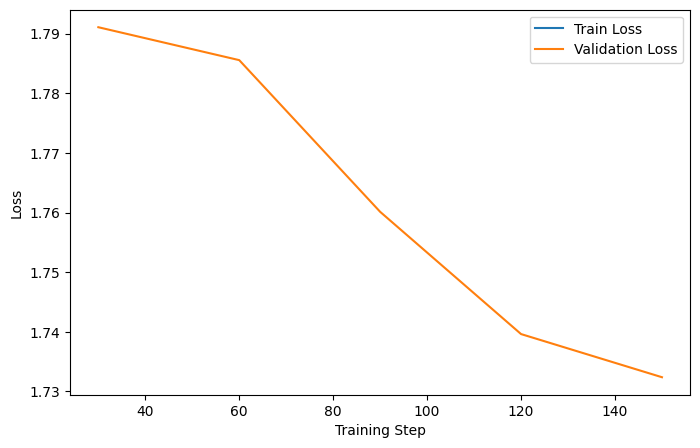

In [17]:
import matplotlib.pyplot as plt

train_loss = history.dropna(subset=["train_loss"])
eval_loss = history.dropna(subset=["eval_loss"])

plt.figure(figsize=(8,5))
plt.plot(train_loss["step"], train_loss["train_loss"], label="Train Loss")
plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
predictions = trainer.predict(dataset['test'])

In [19]:
import numpy as np
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="weighted"))
print("Recall   :", recall_score(y_true, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_true, y_pred, average="weighted"))

Accuracy : 0.8666666666666667
Precision: 0.8806672494172495
Recall   : 0.8666666666666667
F1 Score : 0.8680990270504336


In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Road",
            "Water",
            "Drainage",
            "Health",
            "Electricity",
            "Waste"
        ]
    )
)

              precision    recall  f1-score   support

        Road       0.92      0.92      0.92        12
       Water       0.88      0.78      0.82         9
    Drainage       0.73      0.80      0.76        10
      Health       1.00      0.80      0.89        10
 Electricity       1.00      0.89      0.94         9
       Waste       0.77      1.00      0.87        10

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.87        60
weighted avg       0.88      0.87      0.87        60



In [23]:
!ls muril_sector

checkpoint-120	checkpoint-60  model.safetensors      training_args.bin
checkpoint-150	checkpoint-90  tokenizer_config.json
checkpoint-30	config.json    tokenizer.json


In [28]:
from google.colab import files
files.download('my_model_zip.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import shutil
from google.colab import files
import os

folder_to_zip = '/content/muril_sector'
output_zip_name = 'my_model_zip'

shutil.make_archive(output_zip_name, 'zip', folder_to_zip)

zip_path = f'{output_zip_name}.zip'
zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"✅ Zip created: {zip_path} ({zip_size_mb:.2f} MB)")

files.download(zip_path)
print("📥 Download triggered — check your browser's download bar/folder to confirm it finished.")

✅ Zip created: my_model_zip.zip (8144.42 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download triggered — check your browser's download bar/folder to confirm it finished.


In [29]:
! du -sh muril_sector/*

2.7G	muril_sector/checkpoint-120
2.7G	muril_sector/checkpoint-150
2.7G	muril_sector/checkpoint-30
2.7G	muril_sector/checkpoint-60
2.7G	muril_sector/checkpoint-90
4.0K	muril_sector/config.json
907M	muril_sector/model.safetensors
4.0K	muril_sector/tokenizer_config.json
6.2M	muril_sector/tokenizer.json
8.0K	muril_sector/training_args.bin


In [31]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load your best checkpoint
checkpoint_path = "./muril_sector/checkpoint-150"

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint_path
)

tokenizer = AutoTokenizer.from_pretrained(
    checkpoint_path
)

# Save only final model
model.save_pretrained("./muril_final")

tokenizer.save_pretrained("./muril_final")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./muril_final/tokenizer_config.json', './muril_final/tokenizer.json')

In [32]:
!du -sh muril_final

913M	muril_final


In [33]:
!zip -r muril_final.zip muril_final

  adding: muril_final/ (stored 0%)
  adding: muril_final/model.safetensors (deflated 7%)
  adding: muril_final/tokenizer_config.json (deflated 51%)
  adding: muril_final/config.json (deflated 56%)
  adding: muril_final/tokenizer.json (deflated 70%)


In [35]:
from google.colab import files

files.download("muril_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
# urgency classes
#  0 = low
# 1 = Medium
# 2 = High

In [38]:
# for urgency
import pandas as pd

data2 = [
  {
    "text": "वडा नं. ४ को मुख्य चोकमा ठूलो पहिरो झरेर बाटो पूरै थुनिएको छ र गाडीहरू आउजाउ गर्न सक्ने अवस्था छैन।",
    "label": "HIGH"
  },
  {
    "text": "स्वास्थ्य चौकी अगाडिको बिजुलीको नाङ्गो तार चुँडिएर भुइँमा पानीमाथि छरिएको छ, कसैलाई पनि करेन्ट लाग्न सक्छ।",
    "label": "HIGH"
  },
  {
    "text": "हाम्रो वडा नं. १२ को सुकुम्वासी बस्तीमा एक हप्तादेखि खानेपानीको मुख्य लाइन पूरै बन्द भएर हाहाकार मच्चिएको छ।",
    "label": "HIGH"
  },
  {
    "text": "नदी किनारको पुलमुनिको पिल्लर बाढीले गर्दा धस्सिएको छ, जुनसुकै बेला पनि पुल खस्ने अवस्थामा छ।",
    "label": "HIGH"
  },
  {
    "text": "सरकारी अस्पतालको आकस्मिक कक्ष बाहिर अक्सिजनको अभावमा बिरामीहरूको अवस्था नाजुक बन्दै गएको छ, लौन केही गरौँ।",
    "label": "HIGH"
  },
  {
    "text": "वडा नं. १८ को भित्री गल्लीमा आज बिहानदेखि ढल फुटेर मानव मलमूत्र सिधै स्थानीय इनारको पानीमा मिसिइरहेको छ।",
    "label": "HIGH"
  },
  {
    "text": "विद्यालय नजिकैको ट्रान्सफर्मरबाट ठूलो आवाजसहित आगोको झिल्का निस्किरहेकाले वरपरका घरहरूमा त्रास फैलिएको छ।",
    "label": "HIGH"
  },
  {
    "text": "मुख्य सडकको बीचमै आज दिउँसो ठूलो ढलको ढक्कन बिनाकुनै संकेत खुला छाडिँदा मोटरसाइकल चालकहरू खसिरहेका छन्।",
    "label": "HIGH"
  },
  {
    "text": "हाम्रो टोलको एकमात्र स्वास्थ्य केन्द्रमा विषालु सर्पले टोकेका बिरामीका लागि एन्टिभेनम औषधि नहुँदा मानिसको ज्यान जाँदै छ।",
    "label": "HIGH"
  },
  {
    "text": "पाँच दिनदेखि परिरहेको अविरल वर्षाले गर्दा वडा नं. २ को बस्तीका घरहरूमा पानी पसेर डुबान भएको छ।",
    "label": "HIGH"
  },
  {
    "text": "पुल नजिकैको पुरानो चौतारीको ठूलो रूख जरैदेखि उक्लिन लागेर सिधै पैदलयात्री हिँड्ने बाटोतिर ढल्किएको छ।",
    "label": "HIGH"
  },
  {
    "text": "बजार क्षेत्रको तरकारी मन्डीमा ग्यास सिलिन्डर लिक भएर आगलागी सुरु भइसकेको छ, दमकल कहाँ छ? ",
    "label": "HIGH"
  },
  {
    "text": "वडा नं. ७ को विद्यालय जाने मुख्य काठको पुल मर्मत नगर्दा आज दुई जना बालबालिका खोलामा खसेर बेपत्ता भए।",
    "label": "HIGH"
  },
  {
    "text": "पाँच दिनदेखि बजारको मुख्य सडकमा मरेको गाई सडिरहेकाले कडा दुर्गन्ध फैलिएर महामारी फैलने अवस्था छ।",
    "label": "HIGH"
  },
  {
    "text": "किन वडा नं. ३१ को पहाडी बाटोमा बिना रेलिङ गाडी गुडाउन दिइन्छ, हिजो मात्र एउटा बस भीरबाट खस्नबाट जोगियो?",
    "label": "HIGH"
  },
  {
    "text": "स्वास्थ्य चौकी अगाडिको सडक बीचैबाट दुई चिरा परेर भासिएकाले एम्बुलेन्स समेत भित्र छिर्न पाएका छैनन्।",
    "label": "HIGH"
  },
  {
    "text": "three महिनादेखि शुद्धीकरण नगरिएको फोहोर पानी सिधै वितरण गर्दा वडाभरिका सयौँ बासिन्दा झाडापखालाले थला परे।",
    "label": "HIGH"
  },
  {
    "text": "हाम्रो वडा नं. ५ को मुख्य सडकको मोडमा अत्यधिक तीव्र गतिले गर्दा दैनिक जसो मानिसहरू किचिने अवस्था छ।",
    "label": "HIGH"
  },
  {
    "text": "के यो नगरपालिकाले बजारको सार्वजनिक शौचालयको ढल सिधै खानेपानीको मुहानमा मिसाउँदा पनि नदेखेझैँ गरेको हो?",
    "label": "HIGH"
  },
  {
    "text": "वडा नं. ९ को पुल नजिकै विद्युतको हाइभोल्टेज तार रुखको हाँगामा अल्झिएर धुवाँ निस्किरहेको छ।",
    "label": "HIGH"
  },
  {
    "text": "आज बिहानदेखि वडा कार्यालयको भवनको एउटा पिलर भत्किएर छत खस्न लागेको छ, भित्र कर्मचारी थुनिएका छन्।",
    "label": "HIGH"
  },
  {
    "text": "टोलभरिका सार्वजनिक inarहरूमा रासायनिक फोहोर मिसिएकाले पानी विषाक्त भएको छ, कसैले प्रयोग नगर्नू।",
    "label": "HIGH"
  },
  {
    "text": "सडक खन्ने क्रममा ग्यासको मुख्य पाइपलाइन काटिएर बजार क्षेत्रभरि ग्यासको कडा गन्ध फैलिएको छ।",
    "label": "HIGH"
  },
  {
    "text": "कहिलेसम्म यो पहिरो ग्रस्त क्षेत्रको बाटो प्रयोग गर्ने, हिजो मात्र माथिबाट ढुङ्गा खसेर एक यात्री घाइते भए।",
    "label": "HIGH"
  },
  {
    "text": "हाम्रो वडा नं. १५ को प्राथमिक विद्यालयको पर्खाल भत्केर खेलिरहेका बालबालिकाहरू च्यापिने अवस्थामा पुगेका छन्।",
    "label": "HIGH"
  },
  {
    "text": "एक हप्तादेखि औषधालयमा डेंगुको परीक्षण गर्ने किट र सिटामोल नहुँदा बिरामीहरू छटपटाइरहेका छन्।",
    "label": "HIGH"
  },
  {
    "text": "मुख्य सडकको पुलको गर्डर सरेर गाडी गुड्दा पुल हल्लिने गरेको छ, तुरुन्त सवारी साधन रोक्नुपर्छ।",
    "label": "HIGH"
  },
  {
    "text": "वडा नं. २२ को गल्लीमा रोकिराखेको एसिड बोकेको ट्याङ्कर लीक भएर सडकभरि केमिकल बगिरहेको छ।",
    "label": "HIGH"
  },
  {
    "text": "आजदेखि गाउँको कृषि सेवा केन्द्रमा संकलन गरिएको सबै बिउबिजनमा आगलागी भएर पूरै नष्ट हुन लाग्यो।",
    "label": "HIGH"
  },
  {
    "text": "पुल नजिकैको सडकको ढिस्को भत्किँदा दुई जना पैदलयात्री पुरिएका छन्, उद्धार टोली तुरुन्त पठाइयोस्।",
    "label": "HIGH"
  },
  {
    "text": "वडा नं. ३ को खानेपानी ट्याङ्कीमा कसैले विषालु पदार्थ मिसाएको आशंका छ, पानी वितरण तुरुन्त बन्द गरियोस्।",
    "label": "HIGH"
  },
  {
    "text": "स्वास्थ्य चौकी अगाडिको सडकमा एउटा तेलको ट्याङ्कर पल्टिएर इन्धन जताततै बगिरहेकाले आगो लाग्ने डर भयो।",
    "label": "HIGH"
  },
  {
    "text": "विद्याले नजिकैको सार्वजनिक चौरमा हाई-भोल्टेजको पोल जरैदेखि उख्लिएर झुण्डिएको छ।",
    "label": "HIGH"
  },
  {
    "text": "हाम्रो वडा नं. २६ को अस्पताल जाने एक मात्र सडक पहिरोले पूरै बगाएपछि एम्बुलेन्स आउने बाटो बन्द भयो।",
    "label": "HIGH"
  },
  {
    "text": "तीन दिनदेखि उद्योगबाट निकास भएको केमिकल मिसिएको ढल सिधै बस्तीभित्र पसेर बालबालिकाहरू बिरामी परे।",
    "label": "HIGH"
  },
  {
    "text": "किन बजारको व्यस्त क्रसिङमा ट्राफिक बत्ती र जेब्रा क्रसिङ नहुँदा दैनिक मानिसहरू गाडीको ठक्करबाट मर्दै छन्?",
    "label": "HIGH"
  },
  {
    "text": "वडा नं. ३५ को हिमाली बस्तीमा हिमपहिरोका कारण खानेपानी र खाद्यान्नको लाइन पूरै विच्छेद भएको छ।",
    "label": "HIGH"
  },
  {
    "text": "पुल नजिकैको बाटोमा ठूलो ग्यास पाइपलाइन बिस्फोट भएर वरपरका घरका झ्यालका सिसाहरू फुटेका छन्।",
    "label": "HIGH"
  },
  {
    "text": "आज बिहानदेखि कृषि सेवा केन्द्रको शीतभण्डारको ग्यास लिक भएर वरिपरिका सर्वसाधारण बेहोस हुन थाले।",
    "label": "HIGH"
  },
  {
    "text": "हाम्रो वडा नं. ११ को पुलको दायाँबायाँको माटो नदीले कटान गरेर बस्ती तिर सोझिएको छ।",
    "label": "HIGH"
  },
  {
    "text": "कहिलेसम्म यो जीर्ण विद्युतको तारको मुनि बस्ने, कति बेला आगो लाग्ने हो ठेगान छैन।",
    "label": "HIGH"
  },
  {
    "text": "विद्यालय नजिकै जम्मा भएको उद्योगको फोहोरमा अचानक आगलागी हुँदा विषाक्त धुवाँ कक्षाकोठा भित्र पसेको छ।",
    "label": "HIGH"
  },
  {
    "text": "वडा नं. ८ को मुख्य बजारको गल्लीमा एउटा पुरानो घर भत्केर बाटो हिँड्ने मान्छे पुरिएका छन्।",
    "label": "HIGH"
  },
  {
    "text": "पाँच दिनदेखि ढलको ढक्कन नभएको खाल्डोमा पानी भरिएकाले राति हिँड्ने मानिस डुब्ने अवस्था छ।",
    "label": "HIGH"
  },
  {
    "text": "स्वास्थ्य चौकी अगाडि एउटा पागल कुकुरले आज बिहानैदेखि १० जना बालबालिकालाई टोकेर घाइते बनाइसकेको छ।",
    "label": "HIGH"
  },
  {
    "text": "हाम्रो टोलको ट्रान्सफर्मर पड्किएर तातो तेल सडकमा बगिरहेको छ र बत्ती पूरै निभेको छ।",
    "label": "HIGH"
  },
  {
    "text": "वडा नं. १३ को मुख्य सडकको पुल बीचबाटै भाँच्चिएकाले दुईवटा गाउँको सम्पर्क पूरै टुटेको छ।",
    "label": "HIGH"
  },
  {
    "text": "three महिनादेखि भत्किएको नदीको तटबन्ध यो वर्षाले गर्दा पूरै भत्किएर पानी गाउँतिर पस्यो।",
    "label": "HIGH"
  },
  {
    "text": "किन अस्पतालको आकस्मिक गेट अगाडि नै निर्माण सामग्री थुपारेर एम्बुलेन्स रोक्ने काम गरिन्छ?",
    "label": "HIGH"
  },
  {
    "text": "आजदेखि वडा नं. ३० को पिउने पानीको मुख्य मुहानमा पहिरो खसेर ढुङ्गा माटोले पूरै पुरिएको छ।",
    "label": "HIGH"
  },
  {
    "text": "हाम्रो वडा नं. ६ को भित्री सडकमा साना-साना खाल्डाखुल्डी परेकाले गाडी चलाउँदा अलिअलि हल्लाउने गर्छ।",
    "label": "MEDIUM"
  },
  {
    "text": "कृपया बजार क्षेत्रको खानेपानीको पाइपबाट सामान्य पानी चुहिएर सडक हिलो भएको तर्फ ध्यान दिनुहोला।",
    "label": "MEDIUM"
  },
  {
    "text": "किन वडा नं. १४ को गल्लीमा दुई दिनदेखि फोहोर उठाउने गाडी नआएको, गन्ध आउन थालिसक्यो?",
    "label": "MEDIUM"
  },
  {
    "text": "वडा नं. २ को मुख्य सडकका केही सडकबत्तीहरू एक हप्तादेखि नबलेकाले बेलुका हिँड्न अलि असहज छ।",
    "label": "MEDIUM"
  },
  {
    "text": "पाँच दिनदेखि विद्यालय नजिकैको नाली जाम भएर सडकको कुनाबाट फोहोर पानी बगिरहेको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "यो स्वास्थ्य चौकी अगाडिको फुटपाथ भत्किएकाले वृद्धवृद्धाहरूलाई हिँड्न सामान्य असुविधा भएको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "बारम्बार भन्दा पनि किन कृषि सेवा केन्द्रले यो महिना वितरण गर्ने भनिएको मल अझै उपलब्ध गराएन?",
    "label": "MEDIUM"
  },
  {
    "text": "स्थानीय सार्वजनिक भवनको झ्यालका सिसाहरू बालबालिकाले ढुङ्गा हानेर फुटाएकाले मर्मत गर्नुपर्ने भयो।",
    "label": "MEDIUM"
  },
  {
    "text": "आजदेखि पुल नजिकैको बाटोमा ढलको पाइप सफा नगर्दा पानीको बहाव ढिलो भएको देखिन्छ।",
    "label": "MEDIUM"
  },
  {
    "text": "बजार क्षेत्रको बीच गल्लीमा कसैले निर्माण सामग्री थुपारेकाले गाडीहरूलाई ओभरटेक गर्न गाह्रो भयो।",
    "label": "MEDIUM"
  },
  {
    "text": "टोलभरि हप्तामा दुई दिन मात्र खानेपानी आउने हुँदा दैनिक लुगा धुन र नुहाउन पुग्दैन।",
    "label": "MEDIUM"
  },
  {
    "text": "अहिले वडा नं. ९ को विद्यालय क्षेत्रमा सडक बत्ती मधुरो बलेकाले विद्यार्थीलाई ट्युसन पढेर फर्कन गाह्रो छ।",
    "label": "MEDIUM"
  },
  {
    "text": "सम्बन्धित निकायले वडा नं. २३ को भित्री बाटोको ग्राभेल उप्किँदा पनि किन मर्मत नगरेको होला?",
    "label": "MEDIUM"
  },
  {
    "text": "कहिलेसम्म हाम्रो टोलको फोहोर संकलन गर्ने ट्रयाक्टर हप्ताको एक दिन मात्र आउने हो, दुई दिन बनाइयोस्।",
    "label": "MEDIUM"
  },
  {
    "text": "धेरै पटक निवेदन दिँदा पनि एक महिनादेखि कृषि सेवा केन्द्रको सिँचाइ कुलो सफा गरिएको छैन।",
    "label": "MEDIUM"
  },
  {
    "text": "हाम्रो वडा नं. १६ को सार्वजनिक पुस्तकालयको छानाबाट सामान्य पानी चुहिने समस्या देखिएको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "कृपया पुल नजिकैको मोडमा एउटा गति रोधक ऐना राखिदिनुहोला, घुम्ती अलि साँगुरो छ।",
    "label": "MEDIUM"
  },
  {
    "text": "किन खानेपानी कार्यालयले महिना मरेपछि बिल पठाउँछ तर धारामा पानी भने दिन बिराएर मात्र दिन्छ?",
    "label": "MEDIUM"
  },
  {
    "text": "वडा नं. ३ को स्वास्थ्य चौकीमा ओपिडी टिकट लिने ठाउँमा घाम पानी ओत्ने छानो नहुँदा सास्ती भयो।",
    "label": "MEDIUM"
  },
  {
    "text": "दुई दिनदेखि बजारको मुख्य गल्लीमा फोहोरको बाल्टी भरिएर केही फोहोर बाटोमा खसेको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "यो विद्यालय क्षेत्रमा दिउँसोको समयमा गाडीहरूले ठूलो हर्न बजाउँदा पढाउन निकै बाधा पुगेको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "बारम्बार गुनासो गर्दा पनि वडा नं. १९ को बिजुलीको पोलमा अल्झिएका पुराना तारहरू हटाइएन।",
    "label": "MEDIUM"
  },
  {
    "text": "स्थानीय कृषि हाटबजारमा फोहोर फाल्ने निश्चित ठाउँ नहुँदा व्यापारीहरूले सडकमै फोहोर फाल्ने गरेका छन्।",
    "label": "MEDIUM"
  },
  {
    "text": "आज चोकको सार्वजनिक पार्कको गेटको ताल्चा बिग्रिएकाले सर्वसाधारण भित्र छिर्न पाएका छैनन्।",
    "label": "MEDIUM"
  },
  {
    "text": "बजार क्षेत्रका नालीहरूमा प्लास्टिक जमेकाले पानीको निकास थुनिएर सडक किनारमा पानी जमेको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "टोलभित्रका केही पुराना बिजुलीका काठका पोलहरू मक्किएकाले फलामको फेर्नुपर्ने अवस्था आएको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "अहिले वडा नं. ३४ को पुल नजिकैको बाटो हिलो भएकाले साना गाडी गुड्न अलि गाह्रो छ।",
    "label": "MEDIUM"
  },
  {
    "text": "सम्बन्धित निकायले स्वास्थ्य चौकीमा रिक्त रहेको अहेव पदको कर्मचारी कहिलेसम्म पठाइसक्छ?",
    "label": "MEDIUM"
  },
  {
    "text": "कहिलेसम्म हामीले यो सार्वजनिक भवनको भत्केको भर्याङ प्रयोग गर्ने, मर्मत कहिले हुन्छ?",
    "label": "MEDIUM"
  },
  {
    "text": "धेरै पटक भनियो तर three महिनादेखि कृषि सेवा केन्द्रमा प्राविधिक नहुँदा माटो परीक्षण रोकिएको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "हाम्रो वडा नं. ११ को भित्री सडकमा साना गाडी गुड्दा निकै धुलो उडेर घरभित्र पस्ने गरेको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "कृपया विद्यालय नजिकैको मोडमा गाडीको गति सीमित गर्ने बोर्ड राखिदिनुहुन अनुरोध छ।",
    "label": "MEDIUM"
  },
  {
    "text": "किन हाम्रो टोलको खानेपानीको प्रेसर निकै कम आउँछ, ट्याङ्कीमा पानी तान्न पिस्टन पम्प चाहिन्छ?",
    "label": "MEDIUM"
  },
  {
    "text": "वडा नं. ८ को मुख्य सडकको किनारमा ढल खनेर माटो बाटोमै छाड्दा पैदलयात्रीलाई हिलो भयो।",
    "label": "MEDIUM"
  },
  {
    "text": "एक हप्तादेखि बजारको सार्वजनिक डस्टबिनको बिर्को नहुँदा कागले फोहोर जताततै छरेको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "यो वडा कार्यालयको बैठक हलको पंखा बिग्रिएकाले सेवाग्राहीलाई गर्मीमा बस्न गाह्रो भएको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "बारम्बार आग्रह गर्दा पनि टोलको सडकबत्ती अन/अफ गर्ने स्वीच मर्मत गरिएन, दिउँसो पनि बलिरहन्छ।",
    "label": "MEDIUM"
  },
  {
    "text": "स्थानीय स्वास्थ्य चौकीको एक्स-रे मेसिन सफ्टवेयर बिग्रिएर तीन दिनदेखि सेवा बन्द भएको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "आज बिहान वडा नं. २७ को कृषि फार्म जाने लिङ्क रोडमा एउटा सानो कल्भर्ट भत्कियो।",
    "label": "MEDIUM"
  },
  {
    "text": "बजारको चोकमा सार्वजनिक सवारी साधनले जथाभाबी यात्रु ओराल्दा ट्राफिक जाम बढेको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "टोलभरिका खानेपानीका मिटरहरू पुराना भएकाले रिडिङ स्पष्ट नदेखिने समस्या आएको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "अहिले विद्यालय अगाडिको सडकमा ढलको पानी हल्का बगेकाले विद्यार्थीलाई बाटो काट्न अप्ठ्यारो छ।",
    "label": "MEDIUM"
  },
  {
    "text": "सम्बन्धित निकायले वडा नं. १५ को पशु सेवा केन्द्रको भवनको छाना मर्मत गर्नुपर्छ।",
    "label": "MEDIUM"
  },
  {
    "text": "कहिलेसम्म फोहोरको गाडी ढिलो आउने हो, बिहान ७ बजे आउने गाडी दिउँसो १२ बजे आउँछ।",
    "label": "MEDIUM"
  },
  {
    "text": "धेरै पटक मौखिक जानकारी दिँदा पनि एक महिनादेखि पार्कको भत्केको बेन्च बनाइएको छैन।",
    "label": "MEDIUM"
  },
  {
    "text": "हाम्रो वडा नं. ५ को स्वास्थ्य चौकीमा आयुर्वेदिक औषधिको मौज्दात सकिन लागेको छ।",
    "label": "MEDIUM"
  },
  {
    "text": "कृपया मुख्य सडकको जेब्रा क्रसिङको रङ मेटिएकाले त्यसलाई पुनः स्पष्ट बनाइदिनुहोला।",
    "label": "MEDIUM"
  },
  {
    "text": "किन टोलको नालीको निकास सानो हुँदा सामान्य पानी पर्ने बित्तिकै सडकमा पानी आउँछ?",
    "label": "MEDIUM"
  },
  {
    "text": "वडा नं. ३० को सामुदायिक भवनको सेफ्टी ट्याङ्की भरिन लागेकाले सफा गर्नुपर्ने देखिन्छ।",
    "label": "MEDIUM"
  },
  {
    "text": "पाँच दिनदेखि बजार क्षेत्रको सडक किनारमा काटिएका रुखका हाँगाहरू नहटाउँदा बाटो साँघुरो भयो।",
    "label": "MEDIUM"
  },
  {
    "text": "हाम्रो वडा नं. ७ को सार्वजनिक चौरको दुबो र झाडी धेरै बढेकाले काट्नुपर्ने भएको छ।",
    "label": "LOW"
  },
  {
    "text": "कृपया मुख्य बजारको चोकमा रहेको सहिदको सालिकमा रङरोगन र सरसफाइ गरिदिने व्यवस्था होस्।",
    "label": "LOW"
  },
  {
    "text": "किन वडा नं. ३ को पार्कभित्र बालबालिकाका लागि थप दुईवटा पिङको व्यवस्था नगरिएको होला?",
    "label": "LOW"
  },
  {
    "text": "वडा नं. १० को वडा कार्यालय भवनको अगाडिको भित्तामा नयाँ रङ लगाउन आवश्यक देखिन्छ।",
    "label": "LOW"
  },
  {
    "text": "एक हप्तादेखि विद्यालय नजिकैको चौतारीमा बस्ने काठको फलैँचा अलिकति हल्लिरहेको छ।",
    "label": "LOW"
  },
  {
    "text": "यो नयाँ बनेको पुलको रेलिङमा हरियो रङ लगाए सहरको सौन्दर्य अझ बढ्ने थियो।",
    "label": "LOW"
  },
  {
    "text": "बारम्बार भन्दा पनि किन बजार क्षेत्रका सार्वजनिक खम्बामा टाँसिएका पुराना पोस्टरहरू उखालेर फालिएन?",
    "label": "LOW"
  },
  {
    "text": "स्थानीय कृषि सेवा केन्द्रको परिसरमा थोरै फूलका बोटहरू रोपेर सजाय पाए राम्रो हुन्थ्यो।",
    "label": "LOW"
  },
  {
    "text": "आजदेखि स्वास्थ्य चौकी अगाडिको खाली जग्गामा बिहान टहलिने सानो ट्रयाक बनाउन सुझाव दिन्छु।",
    "label": "LOW"
  },
  {
    "text": "बजार क्षेत्रको मुख्य चोकमा नगरपालिकाको तर्फबाट एउटा डिजिटल घडी राख्न अनुरोध छ।",
    "label": "LOW"
  },
  {
    "text": "टोलभरिका सार्वजनिक भित्ताहरूमा फोहोर फाल्न निषेध लेखिएको साइनबोर्ड झुण्ड्याउन पाए हुन्थ्यो।",
    "label": "LOW"
  },
  {
    "text": "अहिले वडा नं. १ को चोकमा भएको सार्वजनिक धाराको वरिपरि थोरै इँटा छाप्नुपर्ने छ।",
    "label": "LOW"
  },
  {
    "text": "सम्बन्धित निकायले वडा नं. २५ को खुला मञ्चमा बेलुका व्यायाम गर्ने केही उपकरणहरू कहिले राख्छ?",
    "label": "LOW"
  },
  {
    "text": "कहिलेसम्म यो पार्कको फाउन्टेन (पानीको फोहोरा) बन्द रहने हो, मर्मत गरेर चलाइदिए हुन्थ्यो।",
    "label": "LOW"
  },
  {
    "text": "धेरै पटक भनियो तर three महिनादेखि पुस्तकालयको पुराना पत्रिकाहरू राख्ने र्याक फेरिएको छैन।",
    "label": "LOW"
  },
  {
    "text": "हाम्रो वडा नं. १३ को विद्यालयको खेल मैदानको कुनातिर पलाएको झारपात उखेल्न पर्यो।",
    "label": "LOW"
  },
  {
    "text": "कृपया बजारको मुख्य सडकको डिभाइडरमा नयाँ फूलका बिरुवाहरू सार्ने प्रबन्ध मिलाउनुहोस्।",
    "label": "LOW"
  },
  {
    "text": "किन हाम्रो टोलको सार्वजनिक इनारको वरिपरि सुरक्षाका लागि सानो घेराबारा नगरिएको हो?",
    "label": "LOW"
  },
  {
    "text": "वडा नं. २१ को स्वास्थ्य चौकीको भित्री भित्ताहरूमा केही स्वास्थ्य सम्बन्धी चेतनामूलक चित्र बनाउनु पर्यो।",
    "label": "LOW"
  },
  {
    "text": "दुई दिनदेखि पुल नजिकैको पार्कमा राखिएका फोहोरदानीहरू थोरै सरसफाइ गर्नुपर्ने भएको छ।",
    "label": "LOW"
  },
  {
    "text": "यो कृषि बजारको सूचना पाटी अलि सानो भएकाले ठूलो साइजको राख्न अनुरोध गर्दछु।",
    "label": "LOW"
  },
  {
    "text": "बारम्बार ताकेता गर्दा पनि वडा नं. २ को गल्लीका भित्तामा मेटिएका घर नम्बरहरू पुनः लेखिएन।",
    "label": "LOW"
  },
  {
    "text": "स्थानीय सरकारी विद्यालयको गेटमा विद्यालयको नाम स्पष्ट देखिने गरी रङरोगन गर्न सुझाव छ।",
    "label": "LOW"
  },
  {
    "text": "आज चोकमा रहेको जेष्ठ नागरिक मिलन केन्द्रको बलेसी सफा गर्ने व्यवस्था मिलाइयोस्।",
    "label": "LOW"
  },
  {
    "text": "बजार क्षेत्रका पुराना एतिहासिक ढोकाहरूलाई संरक्षण गरी पर्यटकीय रूप दिँदा राम्रो हुन्थ्यो।",
    "label": "LOW"
  },
  {
    "text": "टोलभित्रका बिजुलीका पोलहरूमा जथाभाबी विज्ञापन टाँस्नेहरूलाई कडा चेतावनी दिनुपर्छ।",
    "label": "LOW"
  },
  {
    "text": "अहिले वडा नं. ३२ को नवनिर्मित पिउने पानीको ट्याङ्की बाहिर बुट्टा भर्न मन लागेको छ।",
    "label": "LOW"
  },
  {
    "text": "सम्बन्धित निकायले बजार क्षेत्रका मुख्य गल्लीहरूमा थप १० वटा सजावटी बत्तीहरू राख्नुपर्छ।",
    "label": "LOW"
  },
  {
    "text": "कहिलेसम्म यो खुला चौरलाई यत्तिकै अलपत्र छाड्ने, सानो बगैँचा बनाए त हुन्थ्यो नि।",
    "label": "LOW"
  },
  {
    "text": "धेरै पटक लिखित अनुरोध गर्दा पनि three महिनादेखि वडाको सूचना केन्द्रमा नयाँ नक्सा राखिएन।",
    "label": "LOW"
  },
  {
    "text": "हाम्रो वडा नं. ८ को मुख्य पुलको सुरुवाती पिलरमा स्वागतम बोर्ड झुण्ड्याउन पाए राम्रो हुन्थ्यो।",
    "label": "LOW"
  },
  {
    "text": "कृपया सामुदायिक भवनको मूल गेटको हेन्डल अलि पुरानो भएकाले नयाँ फेरिदिनुहोला।",
    "label": "LOW"
  },
  {
    "text": "किन कृषि सेवा केन्द्रको बैठक कोठामा किसानहरूका लागि बस्ने चकटीहरू थपिएनन्?",
    "label": "LOW"
  },
  {
    "text": "वडा नं. ११ को भित्री सडकको कुनामा रहेको पुरानो ढुङ्गेधाराको संरचनालाई सफा राख्नुपर्ने छ।",
    "label": "LOW"
  },
  {
    "text": "एक महिनादेखि स्वास्थ्य चौकीको प्रतीक्षालयमा पत्रिकाहरू राख्ने स्ट्यान्ड खाली नै देखिन्छ।",
    "label": "LOW"
  },
  {
    "text": "यो पार्कको विश्राम गृहको छानामा केही सुकेका पातहरू जमेकाले हटाउन आवश्यक छ।",
    "label": "LOW"
  },
  {
    "text": "बारम्बार आग्रह गर्दा पनि टोल सुधार समितिले सार्वजनिक कुवाको मर्मत पछि उद्घाटन बोर्ड हालेन।",
    "label": "LOW"
  },
  {
    "text": "स्थानीय चोकको चिया पसल अगाडि एउटा सानो बस्ने बेन्च राखिदिन नगरपालिकालाई सुझाव छ।",
    "label": "LOW"
  },
  {
    "text": "आज बिहान वडा नं. २८ को विद्यालय परिसरमा वृक्षारोपण कार्यक्रमका लागि खाल्डो खनियो।",
    "label": "LOW"
  },
  {
    "text": "बजारको मुख्य सडकको छेउमा रहेका बिजुलीका पोलहरूमा राष्ट्रिय झण्डा राख्न पाए हुन्थ्यो।",
    "label": "LOW"
  },
  {
    "text": "टोलभित्रका रैथाने पुराना ढुङ्गे कुलोहरूलाई पुरानै शैलीमा पुनर्निर्माण गर्न आवश्यक देखिन्छ।",
    "label": "LOW"
  },
  {
    "text": "अहिले विद्यालय नजिकैको सार्वजनिक पार्कमा प्लास्टिकका बोतल हाल्ने अलग्गै टोकरी थप्नुपर्ने छ।",
    "label": "LOW"
  },
  {
    "text": "सम्बन्धित निकायले वडा नं. ९ को योग केन्द्रको भुइँमा म्याट ओछ्याउने व्यवस्था कहिले गर्छ?",
    "label": "LOW"
  },
  {
    "text": "कहिलेसम्म यो बजारको गेट पुरानो र फोहोर देखिने हो, थोरै सेतो रङ लगाइदिए पुग्छ।",
    "label": "LOW"
  },
  {
    "text": "धेरै पटक भनियो तर पार्कको गेटमा फूलको गमला सजाउने काम अझै सुरु भएन।",
    "label": "LOW"
  },
  {
    "text": "हाम्रो वडा नं. ३५ को कार्यालय अगाडि बस्ने ठाउँमा अलिकति छहारीको व्यवस्था करनापर्ने छ।",
    "label": "LOW"
  },
  {
    "text": "कृपया कृषि उपज केन्द्रको सूचना बोर्डको सिसा अलि धमिलो भएकाले सफा गраиदिनुहोला।",
    "label": "LOW"
  },
  {
    "text": "किन पुल नजिकैको पार्कमा बेलुका गीत बजाउने सानो साउन्ड सिस्टम जडान नगरिएको होला?",
    "label": "LOW"
  },
  {
    "text": "वडा नं. १८ को सामुदायिक भवनको बलेसीमा पानी जम्ने भएकाले थोरै ढलान मात्र गरे पुग्छ।",
    "label": "LOW"
  },
  {
    "text": "पाँच दिनदेखि चोकको ठूलो रुखमुनि झरेका सुकेका पातहरू बढारकुँढार गर्न बाँकी छ।",
    "label": "LOW"
  }
]

df = pd.DataFrame(data2)

print("total records", len(df))
print("\nclasses", df['label'].value_counts())

print(df.head())

total records 150

classes label
HIGH      50
MEDIUM    50
LOW       50
Name: count, dtype: int64
                                                text label
0  वडा नं. ४ को मुख्य चोकमा ठूलो पहिरो झरेर बाटो ...  HIGH
1  स्वास्थ्य चौकी अगाडिको बिजुलीको नाङ्गो तार चुँ...  HIGH
2  हाम्रो वडा नं. १२ को सुकुम्वासी बस्तीमा एक हप्...  HIGH
3  नदी किनारको पुलमुनिको पिल्लर बाढीले गर्दा धस्स...  HIGH
4  सरकारी अस्पतालको आकस्मिक कक्ष बाहिर अक्सिजनको ...  HIGH
